In [33]:
import matplotlib.pyplot as plt
import numpy as np
from Bio import SeqIO
import pandas as pd
import csv

aa_properties_ref = {}
properties_list = []
with open('properties/15_aa_properties.csv', 'r') as aa_properties:
    reader = csv.DictReader(aa_properties, delimiter=',')
    for row in reader:
        aa_properties_ref[row["AA_ABREV"]] = {}
        for aa_property in row:
            if aa_property != "AA_ABREV":
                aa_properties_ref[row["AA_ABREV"]][aa_property] = row[aa_property]
                if not aa_property in properties_list:
                    properties_list.append(aa_property)
with open('fasta/c_start_seq_ol.fasta', 'r') as seq_ol:
    aligned_seqs = list(SeqIO.parse(seq_ol, 'fasta'))

aligned_seqs_dict = {}
for seq in aligned_seqs:
    aligned_seqs_dict[seq.id] = str(seq.seq)

binned_data_seqs = {'id':[], 'size':[], 'aligned_seq':[]}

with open('csv/condensation_starter_train_misclassified.csv') as binned_data:
    reader = csv.reader(binned_data, delimiter=',')
    for row in reader:
        if row[1] in ['SCFA', 'MCFA', 'LCFA', 'FA'] and row[3] != '' and row[3] != '32':
            binned_data_seqs['id'].append(row[5])
            binned_data_seqs['size'].append(row[3])
            binned_data_seqs['aligned_seq'].append(aligned_seqs_dict[row[5]])

df2 = pd.DataFrame(binned_data_seqs)
#df2 = df2[df2['size'] != 32]

correlation: 0.46581633571800435


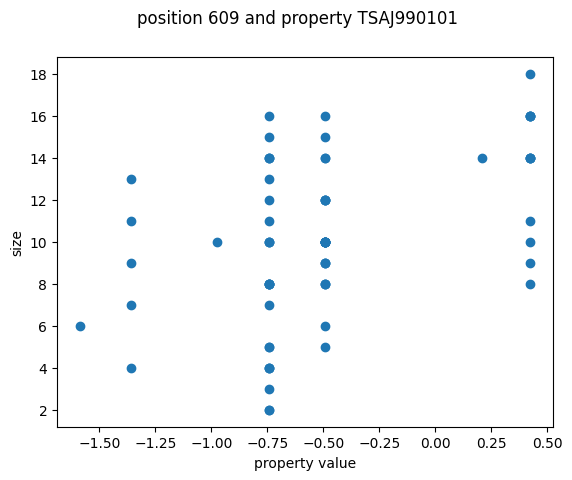

In [63]:
'''
WOLS870101
WOLS870102
WOLS870103
FAUJ880109
GRAR740102
RADA880108
ZIMJ680103
TSAJ990101
CHOP780201
CHOP780202
CHOP780203
ZIMJ680104
NEU1
NEU2
NEU3
'''

POSITION = 609
PROPERTY = 'TSAJ990101'

df2 = pd.DataFrame(binned_data_seqs)
analysis_df = df2.copy()
for pos in range(0,979):
    analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:x[pos])
    analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][PROPERTY])
    analysis_df = analysis_df.copy()
#print(analysis_df)

if analysis_df[str(POSITION)].astype(float).nunique() != 1:
    correlation = np.corrcoef(analysis_df[str(POSITION)].astype(float), analysis_df['size'].astype(int))
    print('correlation:', correlation[0,1])
else:
    print('correlation :', 0)
plt.scatter(analysis_df[str(POSITION)].astype(float), analysis_df['size'].astype(int))
plt.suptitle('position ' + str(POSITION) + ' and property ' + PROPERTY)
plt.xlabel('property value')
plt.ylabel('size')
plt.show()

In [59]:
with open('corr_tables/corr_abs_regression.csv', 'w') as f:
    for i in range(0,979):
        f.write(',' + str(i))
    f.write('\n')


    for prop in aa_properties_ref['A']:
        print(prop)
        f.write(prop)
        analysis_df = df2.copy()
        for pos in range(0,979):
            analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:x[pos])
            analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][prop])
            analysis_df = analysis_df.copy()
            if analysis_df[str(pos)].astype(float).nunique() != 1:
                correlation = np.corrcoef(analysis_df[str(pos)].astype(float), analysis_df['size'].astype(int))[0,1]
                #print('correlation:', correlation)
            else:
                correlation = 0
            f.write(',' + str(abs(correlation)))
        #for pos in range(0,979):
        #    correlation = np.corrcoef(analysis_df[str(pos)].astype(float), analysis_df['size'].astype(int))
        #    print('correlation:', correlation[0,1])
        f.write('\n')

    

WOLS870101
WOLS870102
WOLS870103
FAUJ880109
GRAR740102
RADA880108
ZIMJ680103
TSAJ990101
CHOP780201
CHOP780202
CHOP780203
ZIMJ680104
NEU1
NEU2
NEU3
